# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name: Nainsy Chawla**
**Student ID: 023-24-0261**
**Section: H**
**GitHub: https://github.com/Nainsy-chawla/ML_Lab_Practise**
**Kaggle: https://www.kaggle.com/nainsychawla**
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [18]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [19]:
# Task 1 — load spam.csv, inspect shape/head/class balance

# Load datasets
spam = pd.read_csv("spam.csv", encoding="latin-1")

print("Spam dataset:")
print(spam.shape)
print(spam.head())

# Keep only useful columns
spam = spam[['v1', 'v2']]
spam.columns = ['label', 'message']

print("\nCleaned Spam dataset:")
print(spam.head())
print("Shape:", spam.shape)

# Spam class counts
print("\nSpam class counts:")
print(spam['label'].value_counts())

# Spam class percentages
print("\nSpam class percentages:")
print(spam['label'].value_counts(normalize=True) * 100)


Spam dataset:
(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Cleaned Spam dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Shap

In [20]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets = pd.read_csv("Tweets.csv")
print("\nTweets dataset:")
print(tweets.shape)
print(tweets.head())

# Original sentiment counts
print("\nOriginal sentiment counts:")
print(tweets['airline_sentiment'].value_counts())

# Original sentiment percentages
print("\nOriginal sentiment percentages:")
print(tweets['airline_sentiment'].value_counts(normalize=True) * 100)

tweets = tweets[
    tweets['airline_sentiment'].isin(['positive', 'negative'])
]

# Check remaining data
print("\nTweets after removing neutral:")
print(tweets.shape)

print("\nPositive/Negative counts:")
print(tweets['airline_sentiment'].value_counts())

print("\nPositive/Negative percentages:")
print(tweets['airline_sentiment'].value_counts(normalize=True) * 100)


Tweets dataset:
(14640, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1  

**Answer 2 (Task A — spam):**
The practical problem is to decide automatically whether an incoming SMS should be delivered to the user's inbox or filtered out as spam. It is a binary classification problem because every message belongs to exactly one of two classes: ham (0) or spam (1).

**Answer 2 (Task B — sentiment):**
The practical problem is to classify airline-related tweets by sentiment so that an airline could quickly find unhappy customers and respond to complaints. After removing neutral tweets it becomes a binary classification problem with two classes: negative (0) and positive (1).

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [21]:
# Task 3 — clean text

spam['message'] = spam['message'].str.lower()

spam['message'] = spam['message'].str.replace(
    r'[^\w\s]',
    '',
    regex=True
)

print(spam['message'].head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: str


In [22]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Convert labels into numbers
spam['label'] = spam['label'].map({'ham': 0, 'spam': 1})

# Separate messages and labels
X = spam['message']
y = spam['label']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

# Create vectorizer
vectorizer = CountVectorizer()

# Learn vocabulary only from training data
X_train_vec = vectorizer.fit_transform(X_train)

# Convert test messages using the same vocabulary
X_test_vec = vectorizer.transform(X_test)

print("Training feature shape:", X_train_vec.shape)
print("Testing feature shape:", X_test_vec.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Training messages: 4457
Testing messages: 1115
Training feature shape: (4457, 8347)
Testing feature shape: (1115, 8347)
Vocabulary size: 8347


**Answer 4 (why fit on training data only):**
The vectorizer must be fitted on the training data only because fitting it on the full dataset would let the test messages influence the vocabulary. The test set would then no longer be truly unseen, and the evaluation results would look better than the model's real performance on new messages (data leakage). Words that appear only in test messages are simply ignored by transform, exactly as they would be for messages that arrive after deployment.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9757847533632287
Precision: 0.9552238805970149
Recall: 0.8590604026845637
F1-score: 0.9045936395759717

Confusion Matrix:
[[960   6]
 [ 21 128]]


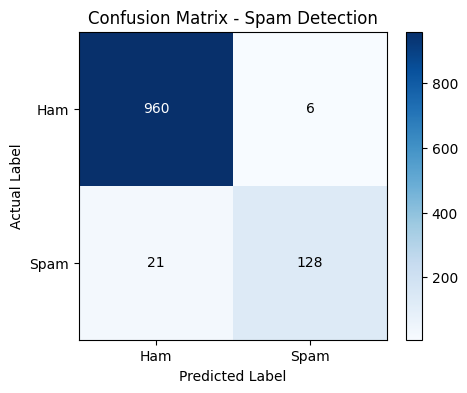

In [23]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

# Create the Naive Bayes model
model = MultinomialNB()

# Train the model
model.fit(X_train_vec, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_vec)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(cm)
#plot the confusion matrix for the spam model

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Spam Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

# write the counts inside each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar()
plt.show()

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [24]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
words = vectorizer.get_feature_names_out()

# Get log probabilities learned by Naive Bayes
log_probs = model.feature_log_prob_

# Difference between spam and ham probabilities
spam_ham_difference = log_probs[1] - log_probs[0]

# Get indices of top 15 spam-associated words
spam_indices = np.argsort(spam_ham_difference)[-15:][::-1]

# Get indices of top 15 ham-associated words
ham_indices = np.argsort(spam_ham_difference)[:15]

print("Top 15 Spam-associated words:")
for i in spam_indices:
    print(words[i], spam_ham_difference[i])

print("\nTop 15 Ham-associated words:")
for i in ham_indices:
    print(words[i], spam_ham_difference[i])

Top 15 Spam-associated words:
claim 5.532821665489798
prize 5.183637393280223
won 5.056482217794977
500 4.616530933615643
tone 4.616530933615643
guaranteed 4.616530933615643
18 4.53429283537867
1000 4.5053052985054185
150 4.380142155551413
150ppm 4.3462406038757315
tcs 4.3462406038757315
awarded 4.311149284064461
urgent 4.256089506881434
collection 4.237041311910739
award 4.197820598757458

Top 15 Ham-associated words:
ltgt -4.437155628315163
ill -4.309322256805278
he -3.880867630472415
lor -3.87308549003036
later -3.7746454172171076
da -3.7659873544739932
she -3.595766204614126
thats -3.415504380783182
my -3.3166385042590036
say -3.2551617307080027
really -3.2551617307080027
doing -3.2551617307080027
didnt -3.24056293128685
ask -3.24056293128685
anything -3.225747845501709


**Answer 7:**
Many of the top spam words match my intuition: "claim", "prize", "won", "guaranteed", "awarded", "award" and "urgent" are typical of prize-scam and promotional messages. Numbers such as "500", "1000", "150" and "18" were also strong spam indicators, because spam often quotes prize amounts, prices and age limits, and tokens like "150ppm", "tcs" and "tone" come from common spam templates. The ham list is mostly informal chat words such as "he", "she", "later", "really", "anything" and "didnt", plus slang like "lor" and "da". Two ham tokens are artifacts: "ltgt" comes from the HTML-escaped symbols in the dataset, and "ill" appeared because removing punctuation turned "i'll" into "ill". Overall the model learned sensible patterns, but its vocabulary depends on the cleaning choices.

In [25]:
# Task 8 — test your own messages
import re

# Same cleaning as the training data: lowercase + remove punctuation
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

my_messages = [
       "Congratulations! You have won a cash prize of 500 dollars.",
    "Hey, are you coming home later?",
    "URGENT! You have been selected for a free prize. Claim now!",
    # deliberately tricky: a normal message that contains a "spam" word
    "Free tonight? Call me when you get this, I won't be late."
]

# Clean the messages with the same function
custom_messages_clean = [clean_text(m) for m in my_messages]

# Convert messages into the same format as training data
custom_vec = vectorizer.transform(custom_messages_clean)

# Predict
custom_predictions = model.predict(custom_vec)
custom_probs = model.predict_proba(custom_vec)[:, 1]

# Display results
for message, prediction, p in zip(my_messages, custom_predictions, custom_probs):
    print("Message:", message)
    print("Prediction:", "Spam" if prediction == 1 else "Ham", f"(P(spam) = {p:.3f})")
    print()



Message: Congratulations! You have won a cash prize of 500 dollars.
Prediction: Spam (P(spam) = 1.000)

Message: Hey, are you coming home later?
Prediction: Ham (P(spam) = 0.000)

Message: URGENT! You have been selected for a free prize. Claim now!
Prediction: Spam (P(spam) = 1.000)

Message: Free tonight? Call me when you get this, I won't be late.
Prediction: Ham (P(spam) = 0.000)



**Answer 8:**
I tested four custom messages using the same cleaning as the training data. The model predicted spam for the two spam-like messages (P(spam) = 1.000), ham for the normal message (0.000), and ham for a tricky normal message containing "free" (0.000). All four matched my expectations. The tricky message was classified correctly because its conversational words ("call", "tonight", "late") outweighed the single spam-like word. The extreme probabilities occur because Naive Bayes treats each word as independent evidence and multiplies them, which makes it very confident._

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/nainsychawla/naive-bayes-spam-detection

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [26]:
# Task 11 — clean and vectorize the sentiment data 
tweets['text'] = (tweets['text'].str.lower()
                  .str.replace(r'@\w+', '', regex=True)          # mentions
                  .str.replace(r'http\S+|www\S+', '', regex=True) # links
                  .str.replace(r'[^\w\s]', '', regex=True)        # punctuation
                  .str.replace(r'\s+', ' ', regex=True).str.strip())

tweets['airline_sentiment'] = tweets['airline_sentiment'].map({'negative': 0, 'positive': 1})

X_sent = tweets['text']
y_sent = tweets['airline_sentiment']

X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent)

sent_vectorizer = CountVectorizer()
X_train_sent_vec = sent_vectorizer.fit_transform(X_train_sent)  # fit on train only
X_test_sent_vec = sent_vectorizer.transform(X_test_sent)

print("Train/Test:", len(X_train_sent), len(X_test_sent))
print("Vocabulary size:", len(sent_vectorizer.vocabulary_))

Train/Test: 9232 2309
Vocabulary size: 11138


**Answer 12:**
Besides lowercasing and removing punctuation, I removed @mentions and URLs. Tweets contain airline handles and links that say nothing about sentiment, and they would add many rare, noisy features. SMS messages had far fewer of these, so Task A didn't need this step.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

0.9029883066262451 0.9307958477508651 0.5687103594080338 0.7060367454068242


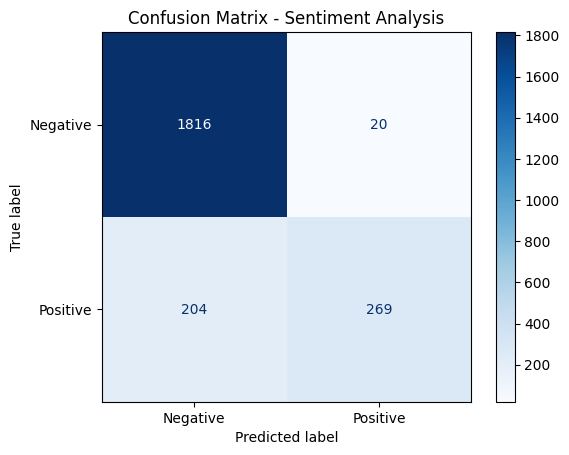

In [27]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
sent_model = MultinomialNB()
sent_model.fit(X_train_sent_vec, y_train_sent)
y_pred_sent = sent_model.predict(X_test_sent_vec)

acc_s = accuracy_score(y_test_sent, y_pred_sent)
prec_s = precision_score(y_test_sent, y_pred_sent)
rec_s = recall_score(y_test_sent, y_pred_sent)
f1_s = f1_score(y_test_sent, y_pred_sent)
print(acc_s, prec_s, rec_s, f1_s)

cm_s = confusion_matrix(y_test_sent, y_pred_sent)
ConfusionMatrixDisplay(cm_s, display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.9030|
| Precision |0.9308|
| Recall |0.5687|
| F1-score |0.7060|

**Answer 14:**
Naive Bayes did worse on sentiment than on spam. Accuracy was 90.30% against 97.58%, and F1 was 70.60% against 90.46%. The biggest gap is recall: 56.87% for positive tweets against 85.91% for spam, so 204 of the 473 positive tweets were missed. The independence assumption fits spam better, because single trigger words like "prize" or "claim" are strong evidence on their own. Sentiment depends on word combinations, negation ("not good") and sarcasm, and Naive Bayes treats every word separately. Also, about 79.5% of the tweets are negative, so the 90.30% accuracy is less impressive than it looks, since always predicting "negative" would already score about 79.5%. The class imbalance pushes the model toward negative, and that also lowers recall on the positive class.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/nainsychawla/airline-tweet-sentiment-analysis-using-naive-bayes

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy |0.9758 |0.9030 |
| Precision |0.9552 |0.9308 |
| Recall |0.8591 |0.5687 |
| F1-score |0.9046 |0.7060 |

In [28]:
# Task 18 — Logistic Regression on Task A's vectorized features
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

print(accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
      recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

0.9820627802690582 0.9849624060150376 0.8791946308724832 0.9290780141843972
[[964   2]
 [ 18 131]]


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy |0.9758 |0.9821 |
| Precision |0.9552 |0.9850 |
| Recall |0.8591 |0.8792 |
| F1-score |0.9046 |0.9291 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression won on all four metrics. False positives dropped from 6 to 2 and false negatives from 21 to 18. This is what I expected, because Logistic Regression learns one weight per word jointly, while Naive Bayes assumes words are independent and can double-count correlated words. The gap is small, though, so Naive Bayes is still a strong, fast baseline for spam. I didn't test the independence assumption directly, so other differences in training may also play a part.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes suited the spam task better than the sentiment task (97.58% accuracy and 90.46% F1 against 90.30% and 70.60%). Spam depends on individual trigger words that act as roughly independent evidence. What surprised me about the top words was that numbers like "500", "1000" and "18" were strong spam signals. The ham list also contained artifacts like "ltgt" and "ill", which my own punctuation removal created, so the vocabulary depends heavily on the cleaning choices. On the same spam features, Logistic Regression beat Naive Bayes (98.21% accuracy and 92.91% F1), consistent with it learning word weights jointly. The limitation of the independence assumption that I saw myself was on the tweets: recall for positive tweets was only 56.87%, because the model can't capture negation, sarcasm or context. Class imbalance (about 80% negative) also hurt that recall, so accuracy alone was misleading. For spam I would prioritize precision, so real messages are never hidden from the user.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/nainsychawla/naive-bayes-spam-detection
- Task B: https://www.kaggle.com/code/nainsychawla/airline-tweet-sentiment-analysis-using-naive-bayes

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted